# 📝 Instrucciones: Campaña de Marketing Bancario

## 1. Comprensión empresarial
Los **depósitos a largo plazo** permiten a los bancos retener capital durante un período específico, facilitando la inversión de estos fondos en otros activos financieros. 

Actualmente, las campañas de marketing para este producto se realizan mediante **llamadas telefónicas**. Si un usuario no está disponible, se programa una nueva llamada para un momento posterior.

## 2. Descripción del problema
Un banco portugués ha detectado una disminución en sus ingresos. Para revertir esta tendencia, necesitan identificar a los clientes existentes con **mayor probabilidad de contratar un depósito a largo plazo**.

**Objetivo:** Crear un algoritmo de clasificación que prediga la suscripción del cliente para optimizar los esfuerzos de marketing, ahorrando tiempo y recursos.

---

## 3. Pasos del Proyecto

### Paso 1: Carga del conjunto de datos
El archivo se encuentra en el repositorio como `bank-marketing-campaign-data.csv`. Puedes cargarlo directamente desde este enlace:

> 🔗 [Descargar Dataset](https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv)

#### Diccionario de Datos:
| Variable | Descripción | Tipo |
| :--- | :--- | :--- |
| **age** | Edad del cliente | Numérico |
| **job** | Tipo de trabajo | Categórico |
| **marital** | Estado civil | Categórico |
| **education** | Nivel de educación | Categórico |
| **default** | ¿Tiene crédito actualmente? | Categórico |
| **housing** | ¿Tiene un préstamo de vivienda? | Categórico |
| **loan** | ¿Tiene un préstamo personal? | Categórico |
| **contact** | Tipo de comunicación de contacto | Categórico |
| **month** | Último mes de contacto | Categórico |
| **day_of_week** | Último día de contacto | Categórico |
| **duration** | Duración del último contacto (segundos) | Numérico |
| **campaign** | Número de contactos en esta campaña | Numérico |
| **pdays** | Días desde el último contacto en campaña previa | Numérico |
| **previous** | Número de contactos previos a esta campaña | Numérico |
| **poutcome** | Resultado de la campaña de marketing anterior | Categórico |
| **emp.var.rate** | Tasa de variación del empleo (trimestral) | Numérico |
| **cons.price.idx**| Índice de precios al consumidor (mensual) | Numérico |
| **cons.conf.idx** | Índice de confianza del consumidor (mensual) | Numérico |
| **euribor3m** | Tasa EURIBOR 3 meses (diario) | Numérico |
| **nr.employed** | Número de empleados (trimestral) | Numérico |
| **y (TARGET)** | ¿El cliente contrata el depósito? | **Categórico** |

### Paso 2: Análisis Exploratorio de Datos (EDA)
Es fundamental realizar un EDA completo para filtrar variables irrelevantes.
* Adapta el Notebook de ejemplo a este caso de uso.
* **Importante:** Divide el conjunto de datos en los sets de **entrenamiento (train)** y **prueba (test)**.

### Paso 3: Construcción del modelo
Construye un modelo de **Regresión Logística**. 
* En esta etapa, utiliza la configuración por defecto de la librería para establecer una línea base.

### Paso 4: Optimización
Si los resultados iniciales no son satisfactorios, aplica técnicas de optimización de hiperparámetros o ingeniería de variables para mejorar la precisión del modelo.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import json
import matplotlib.gridspec as gridspec
import os
from sklearn.model_selection import train_test_split

In [38]:
# Cargamos el dataset usamos el delimitador ";"
total_data = pd.read_csv('../data/raw/bank-marketing-campaign-data.csv',delimiter=";")
#separamos los datos en train, test
train, test = train_test_split(total_data, test_size=0.2, random_state=7)
#imprimimos los primeros 5
total_data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [39]:
#imprimimos el numero de filas
print(f"Numero De Filas en 'total_data': {len(total_data)}")
print(f"Numero De Filas en 'train': {len(train)}")
print(f"Numero De Filas en 'test': {len(test)}")
# Verificamos La Cantidad De Variables Por Tipos De Datos en train que son los datos que vamos a aplicar el EDA:
pd.Series.value_counts(train.dtypes)

Numero De Filas en 'total_data': 41188
Numero De Filas en 'train': 32950
Numero De Filas en 'test': 8238


str        11
int64       5
float64     5
Name: count, dtype: int64

In [40]:
#Obtenemos Información Sobre Los Tipos De Datos Y Valores No Nulos
print("------------------INFO DE TRAIN--------------------\n")
info = train.info()
print("\n\n\n")
print("------------------PORCENTAJE DE VALORES NULOS DEL TRAIN---------------------\n")
#Obtenemos que columnas tienen valores nulos y el que porcentage respectivamente
(train.isna().sum() / len(train) * 100).sort_values(ascending = False)

------------------INFO DE TRAIN--------------------

<class 'pandas.DataFrame'>
Index: 32950 entries, 8871 to 10742
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             32950 non-null  int64  
 1   job             32950 non-null  str    
 2   marital         32950 non-null  str    
 3   education       32950 non-null  str    
 4   default         32950 non-null  str    
 5   housing         32950 non-null  str    
 6   loan            32950 non-null  str    
 7   contact         32950 non-null  str    
 8   month           32950 non-null  str    
 9   day_of_week     32950 non-null  str    
 10  duration        32950 non-null  int64  
 11  campaign        32950 non-null  int64  
 12  pdays           32950 non-null  int64  
 13  previous        32950 non-null  int64  
 14  poutcome        32950 non-null  str    
 15  emp.var.rate    32950 non-null  float64
 16  cons.price.idx  32950 non-null  floa

age               0.0
job               0.0
marital           0.0
education         0.0
default           0.0
housing           0.0
loan              0.0
contact           0.0
month             0.0
day_of_week       0.0
duration          0.0
campaign          0.0
pdays             0.0
previous          0.0
poutcome          0.0
emp.var.rate      0.0
cons.price.idx    0.0
cons.conf.idx     0.0
euribor3m         0.0
nr.employed       0.0
y                 0.0
dtype: float64

# Conclusiones (Hasta Ahora):
* Tenemos un dataframe TRAIN con 20 columnas y 32950  filas
* 5 columnas son int64, 11 str y 5 float64
* Ninguna de esas columnas tienen valores nulos.

In [41]:
# En el ejercicio anterior graficamos los valores nulos pero en este caso no nos encontramos con nulos en ninguna de las variables
# Ahora procederiamos a eliminar duplicados pero no tenemos una columna "id_<algo>" que podamos identificar como primaria de una base de datos en el csv entonses pasamos a
# Revisar Los Posibles Datos Categóricos
train.select_dtypes(include = ['str']).columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')

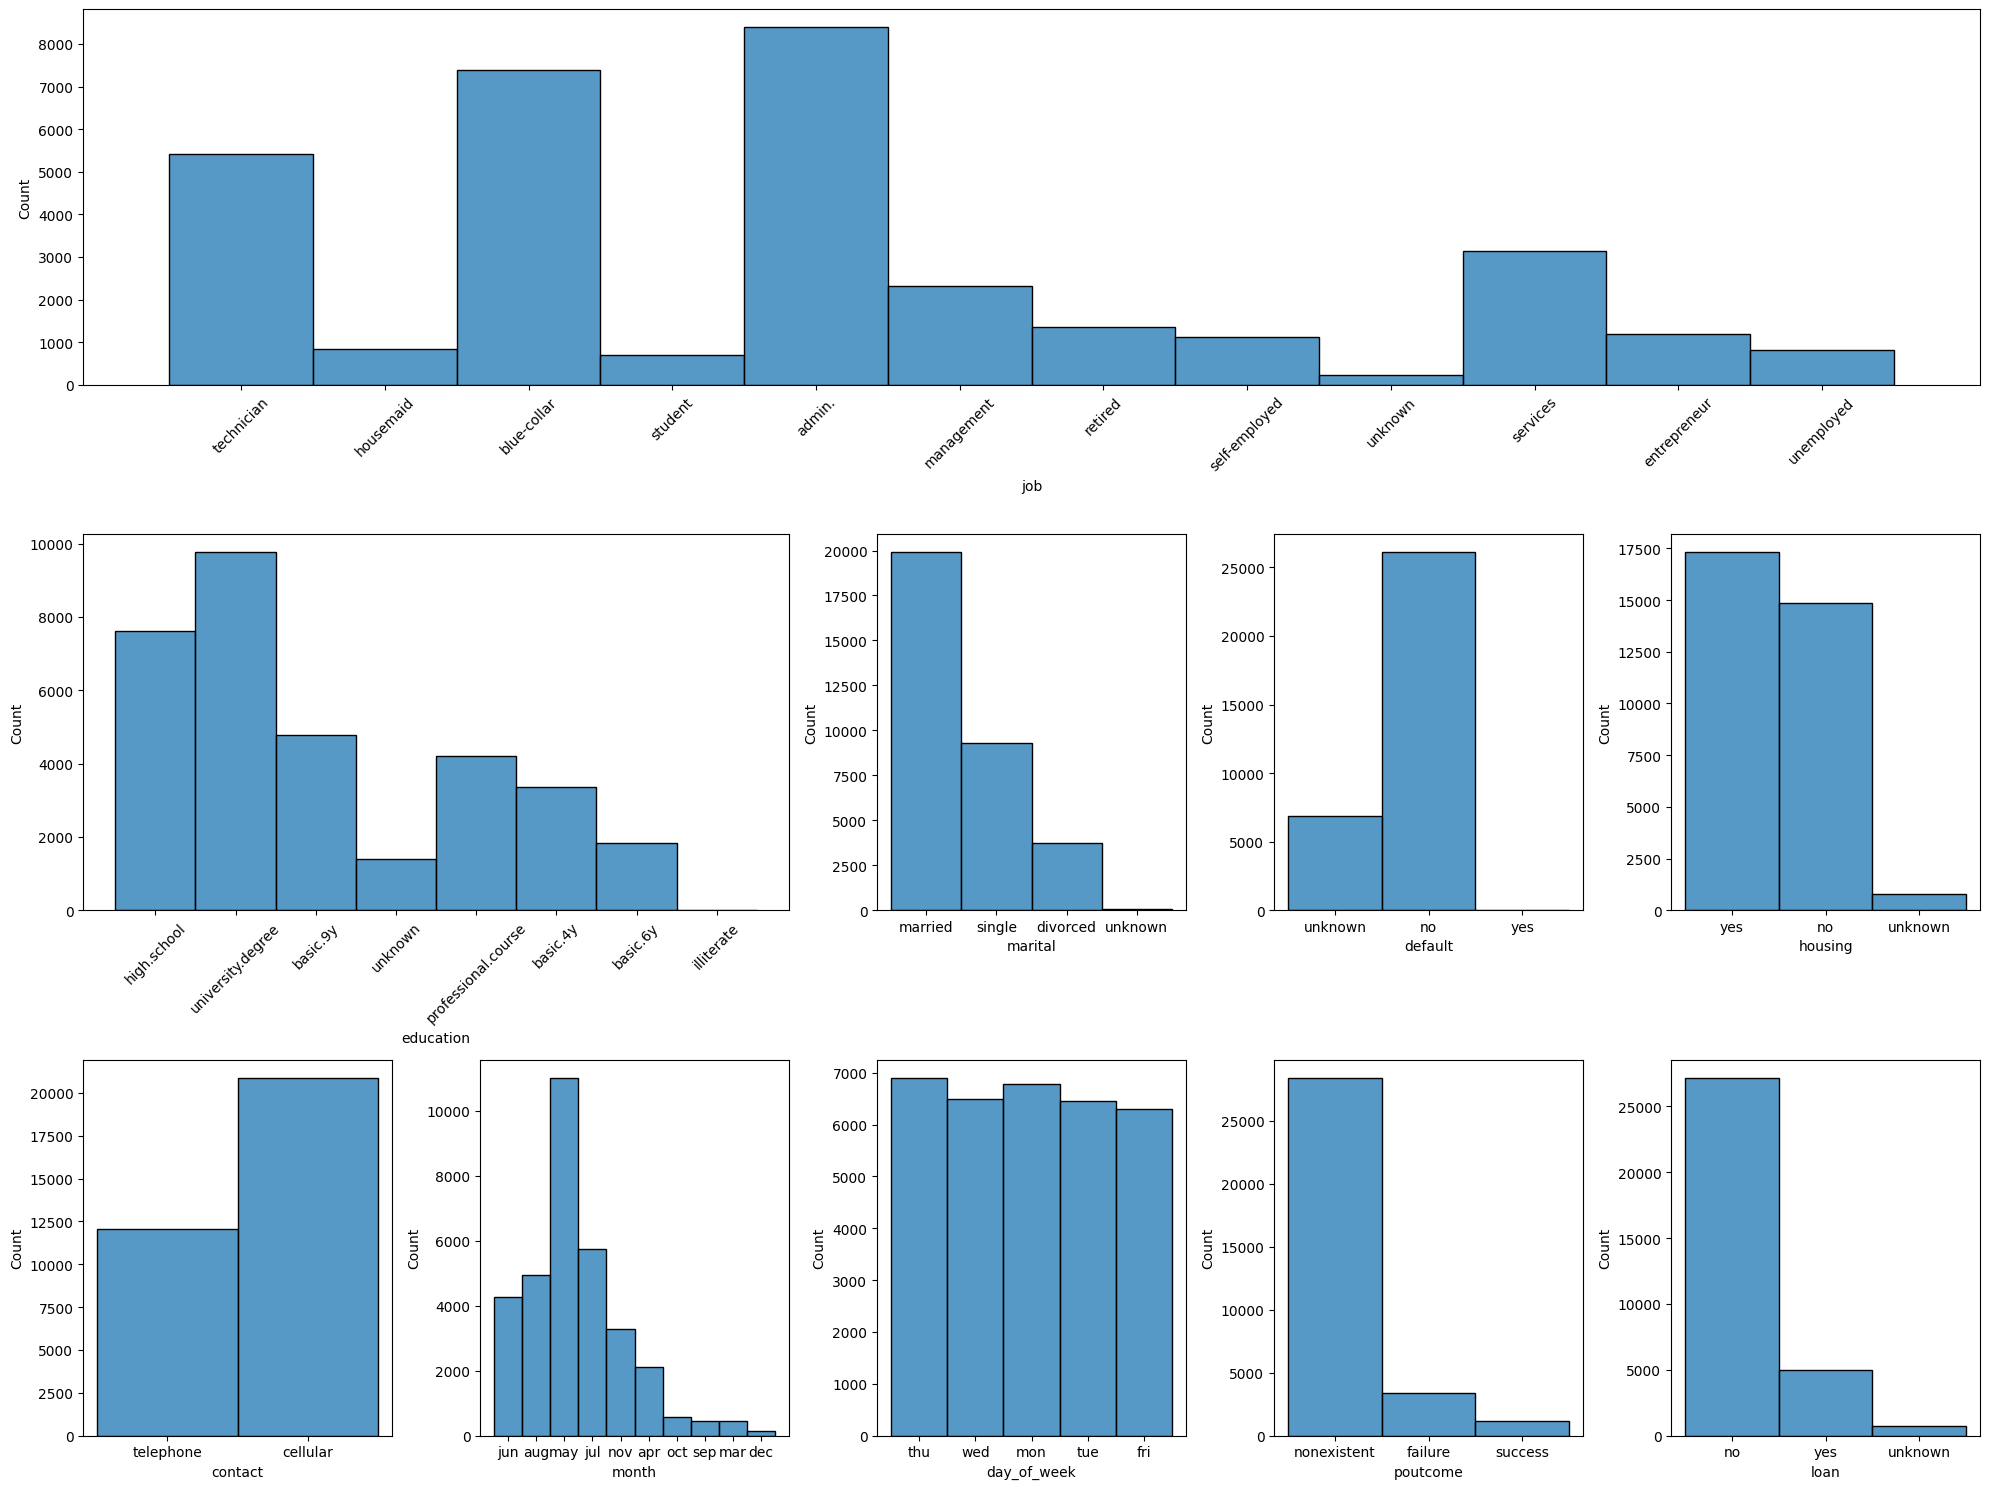

In [42]:
#Creamos Un Histograma Múltiple
fig = plt.figure(figsize=(20, 15))
#Creamos un grid porque necesitaremos hacer unos ajustes de tamaños en algunos graficos, el grid va a ser de 3x5
axis = gridspec.GridSpec(3, 5, figure=fig)
#le decimos al primer grid que ocupe toda la fila
axis0 = fig.add_subplot(axis[0, :])
sns.histplot(data=train, x='job', ax=axis0)
#y rotamos un poco los labels
axis0.tick_params(axis='x', rotation=45)
#el segundo grafico va a ocupar 2 espacios
axis1 = fig.add_subplot(axis[1,0:2]); sns.histplot(data=train, x='education', ax=axis1)
axis1.tick_params(axis='x', rotation=45)
#el resto solo uno
axis2 = fig.add_subplot(axis[1,2]); sns.histplot(data=train, x='marital', ax=axis2)
axis3 = fig.add_subplot(axis[1,3]); sns.histplot(data=train, x='default', ax=axis3)
axis4 = fig.add_subplot(axis[1,4]); sns.histplot(data=train, x='housing', ax=axis4)
axis6 = fig.add_subplot(axis[2,0]); sns.histplot(data=train, x='contact', ax=axis6)
axis7 = fig.add_subplot(axis[2,1]); sns.histplot(data=train, x='month', ax=axis7)
axis8 = fig.add_subplot(axis[2,2]); sns.histplot(data=train, x='day_of_week', ax=axis8)
axis9 = fig.add_subplot(axis[2,3]); sns.histplot(data=train, x='poutcome', ax=axis9)
axis5 = fig.add_subplot(axis[2,4]); sns.histplot(data=train, x='loan', ax=axis5)

#Ajustar Layaut
plt.tight_layout()
#Mostramos El Plot
plt.show()

### Son Categorizables?:
#### Analisis e Interpretacion De Columnas(Variables):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **job** | Tipo de trabajo | Puesto que en ciertos trabajos se manejan conceptos economicos puede servir para nuestro target, ademas el nivel adquisitivo ofrece mas seguridad a la hora de invertir.
| **marital** | Estado civil | Personas solteras suelen tener menos gastos, aunque esto varia si tiene hijos o no, igual son mas propensos a invertir. 
| **education** | Nivel de educación | Parecido al la variable job puede dar señales de conocimientos economicos y de inversion.
| **default** | ¿Tiene crédito actualmente? | Si usuario posee un credito, aunque use un servicio del banco, forma parte del "Dame dinero" y no del "Tomalo e inviertelo" pero el grafico demuestra que la gran mayoria no posee credito actualmente, y el resto se desconoce, se va a descartar esta columna porque no aporta info.
| **housing** | ¿Tiene un préstamo de vivienda? | Igual que el punto anterior pero aca si tenemos datos diversos por lo que lo tendremos en cuenta.
| **loan** | ¿Tiene un préstamo personal? | Igual que el punto anterior aunque disparejo en si posee prestamo o no por lo menos tenemos algunos valores en "yes".
| **contact** | Tipo de comunicación de contacto | Como vimos en el enunciado se suelen ofrecer estos servicios por llamadas puede ser por telefono o celular
| **month** | Último mes de contacto | Si un cliente respondio negativamente a el ultimo contacto, es mas posible que cambie de opinion mientras mas tiempo pase desde el ultimo contacto.
| **day_of_week** | Último día de contacto | Es menos especifico que la variable anterior y pueden solaparse, se puede crear una variable conjunta, el grafico muestra mucha paridad por lo que no nos aporta info relevante por si sola.
| **poutcome** | Resultado de la campaña de marketing anterior | Puede ser usable pero el grafico muestra una mayoria en noexistente, una parte en failiure y un muy minimo "success" que va con la problematica del target quizas haya informacion relevante en esos pocos success. 
| **y (TARGET)** | ¿El cliente contrata el depósito? | Es nuestro Target.
#### Variables Categorizables: 
* job
* marital
* education
* housing
* loan
* contact
* month
* poutcome
* day_of_week
* y
 
 

In [43]:
#reuso mi funcion del ejercicio anterior para guardar cambios en un json pero le modifique que creara el factor el mismo, elimine de una y nombrara la columna factor automaticamente: 
def create_factor_transf_and_json(column, df,folder_name, transformation = False,transformation_func = lambda x: x):
    file_name = ""
        
    if transformation:
         # ahora se le pasa a la funcion una funcion de trnasformacion
        df_aux = df[[column]].copy()
        df[column+"_transf"] = df_aux[column].apply(transformation_func)
        folder_path = '../data/processed/tranformations/' + folder_name
        df_aux = df[[column,column+"_transf"]].copy()
    else:
        #Creo la columna Factor
        df[column+"_factor"] = pd.factorize(df[column])[0]
        folder_path = '../data/processed/factories/' + folder_name
        df_aux = df[[column, column+"_factor"]].copy()
        
    #crea la carpeta si no existe
    os.makedirs(folder_path, exist_ok=True)

    for col in df_aux.columns:
        if pd.api.types.is_datetime64_any_dtype(df_aux[col]):
            df_aux[col] = df_aux[col].dt.strftime('%Y-%m-%d')
    
    if transformation:
        file_name = f'{column}_transformation_rules.json'
        df_to_save = df_aux[[column, column+"_transf"]]
        data_to_export = df_to_save.to_dict(orient = 'records')
    else:
      
        file_name = f'{column}_factory_rules.json'
        df_unique = df_aux[[column, column+"_factor"]].drop_duplicates()
        data_to_export = {row[column]: row[column+"_factor"] for _, row in df_unique.iterrows()}

    full_path = os.path.join(folder_path, file_name)
    with open(full_path, 'w') as f:
        json.dump(data_to_export, f, indent=4)
    #elimino la columna antigua antigua
    df.drop([column],  axis = 1,  inplace = True)
    print(f"Json guardado en: {full_path}")

    

## Rellenar Valores Unknown?:
    En este caso mas que valores erroneos, son desconocimiento de la informacion asi que voy a dejar "Unknown" en las columnas que las tienen como una categoria mas

In [44]:
#Factorizamos las variables categoricas con la funcion "create_factor_transf_and_json_pro_max_2026_full_4k_mediafire_etc"

create_factor_transf_and_json("job", train,"BancoEjercicio2")
create_factor_transf_and_json("marital", train,"BancoEjercicio2")
create_factor_transf_and_json("education", train,"BancoEjercicio2")
create_factor_transf_and_json("housing", train,"BancoEjercicio2")
create_factor_transf_and_json("loan", train,"BancoEjercicio2")
create_factor_transf_and_json("contact", train,"BancoEjercicio2")
create_factor_transf_and_json("month", train,"BancoEjercicio2")
create_factor_transf_and_json("poutcome", train,"BancoEjercicio2")
create_factor_transf_and_json("day_of_week", train,"BancoEjercicio2")
create_factor_transf_and_json("y", train,"BancoEjercicio2")
train



Json guardado en: ../data/processed/factories/BancoEjercicio2\job_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\marital_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\education_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\housing_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\loan_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\contact_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\month_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\poutcome_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\day_of_week_factory_rules.json
Json guardado en: ../data/processed/factories/BancoEjercicio2\y_factory_rules.json


,age,default,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,...,job_factor,marital_factor,education_factor,housing_factor,loan_factor,contact_factor,month_factor,poutcome_factor,day_of_week_factor,y_factor
8871,37,unknown,218,1,999,0,1.4,94.465,-41.8,4.866,...,0,0,0,0,0,0,0,0,0,0
23616,42,no,2372,3,999,0,1.4,93.444,-36.1,4.962,...,1,0,1,0,1,1,1,0,0,1
11023,25,no,121,2,999,0,1.4,94.465,-41.8,4.962,...,2,0,2,0,0,0,0,0,1,0
30525,31,no,63,3,999,0,-1.8,92.893,-46.2,1.354,...,3,1,3,1,1,1,2,0,2,0
9932,36,no,183,9,999,0,1.4,94.465,-41.8,4.959,...,0,0,4,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34140,29,no,12,5,999,0,-1.8,92.893,-46.2,1.281,...,4,0,1,1,0,1,2,0,1,0
13927,35,no,60,2,999,0,1.4,93.918,-42.7,4.963,...,4,1,1,1,0,1,3,0,4,0
919,32,no,180,2,999,0,1.1,93.994,-36.4,4.856,...,9,1,0,0,0,0,2,0,1,0
38467,33,no,61,2,6,2,-3.4,92.431,-26.9,0.731,...,4,1,0,0,0,1,6,1,2,0


In [45]:
# Ahora seleccionamos variables numericas
train.select_dtypes(include = ['int', 'float']).columns

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_factor', 'marital_factor', 'education_factor', 'housing_factor',
       'loan_factor', 'contact_factor', 'month_factor', 'poutcome_factor',
       'day_of_week_factor', 'y_factor'],
      dtype='str')

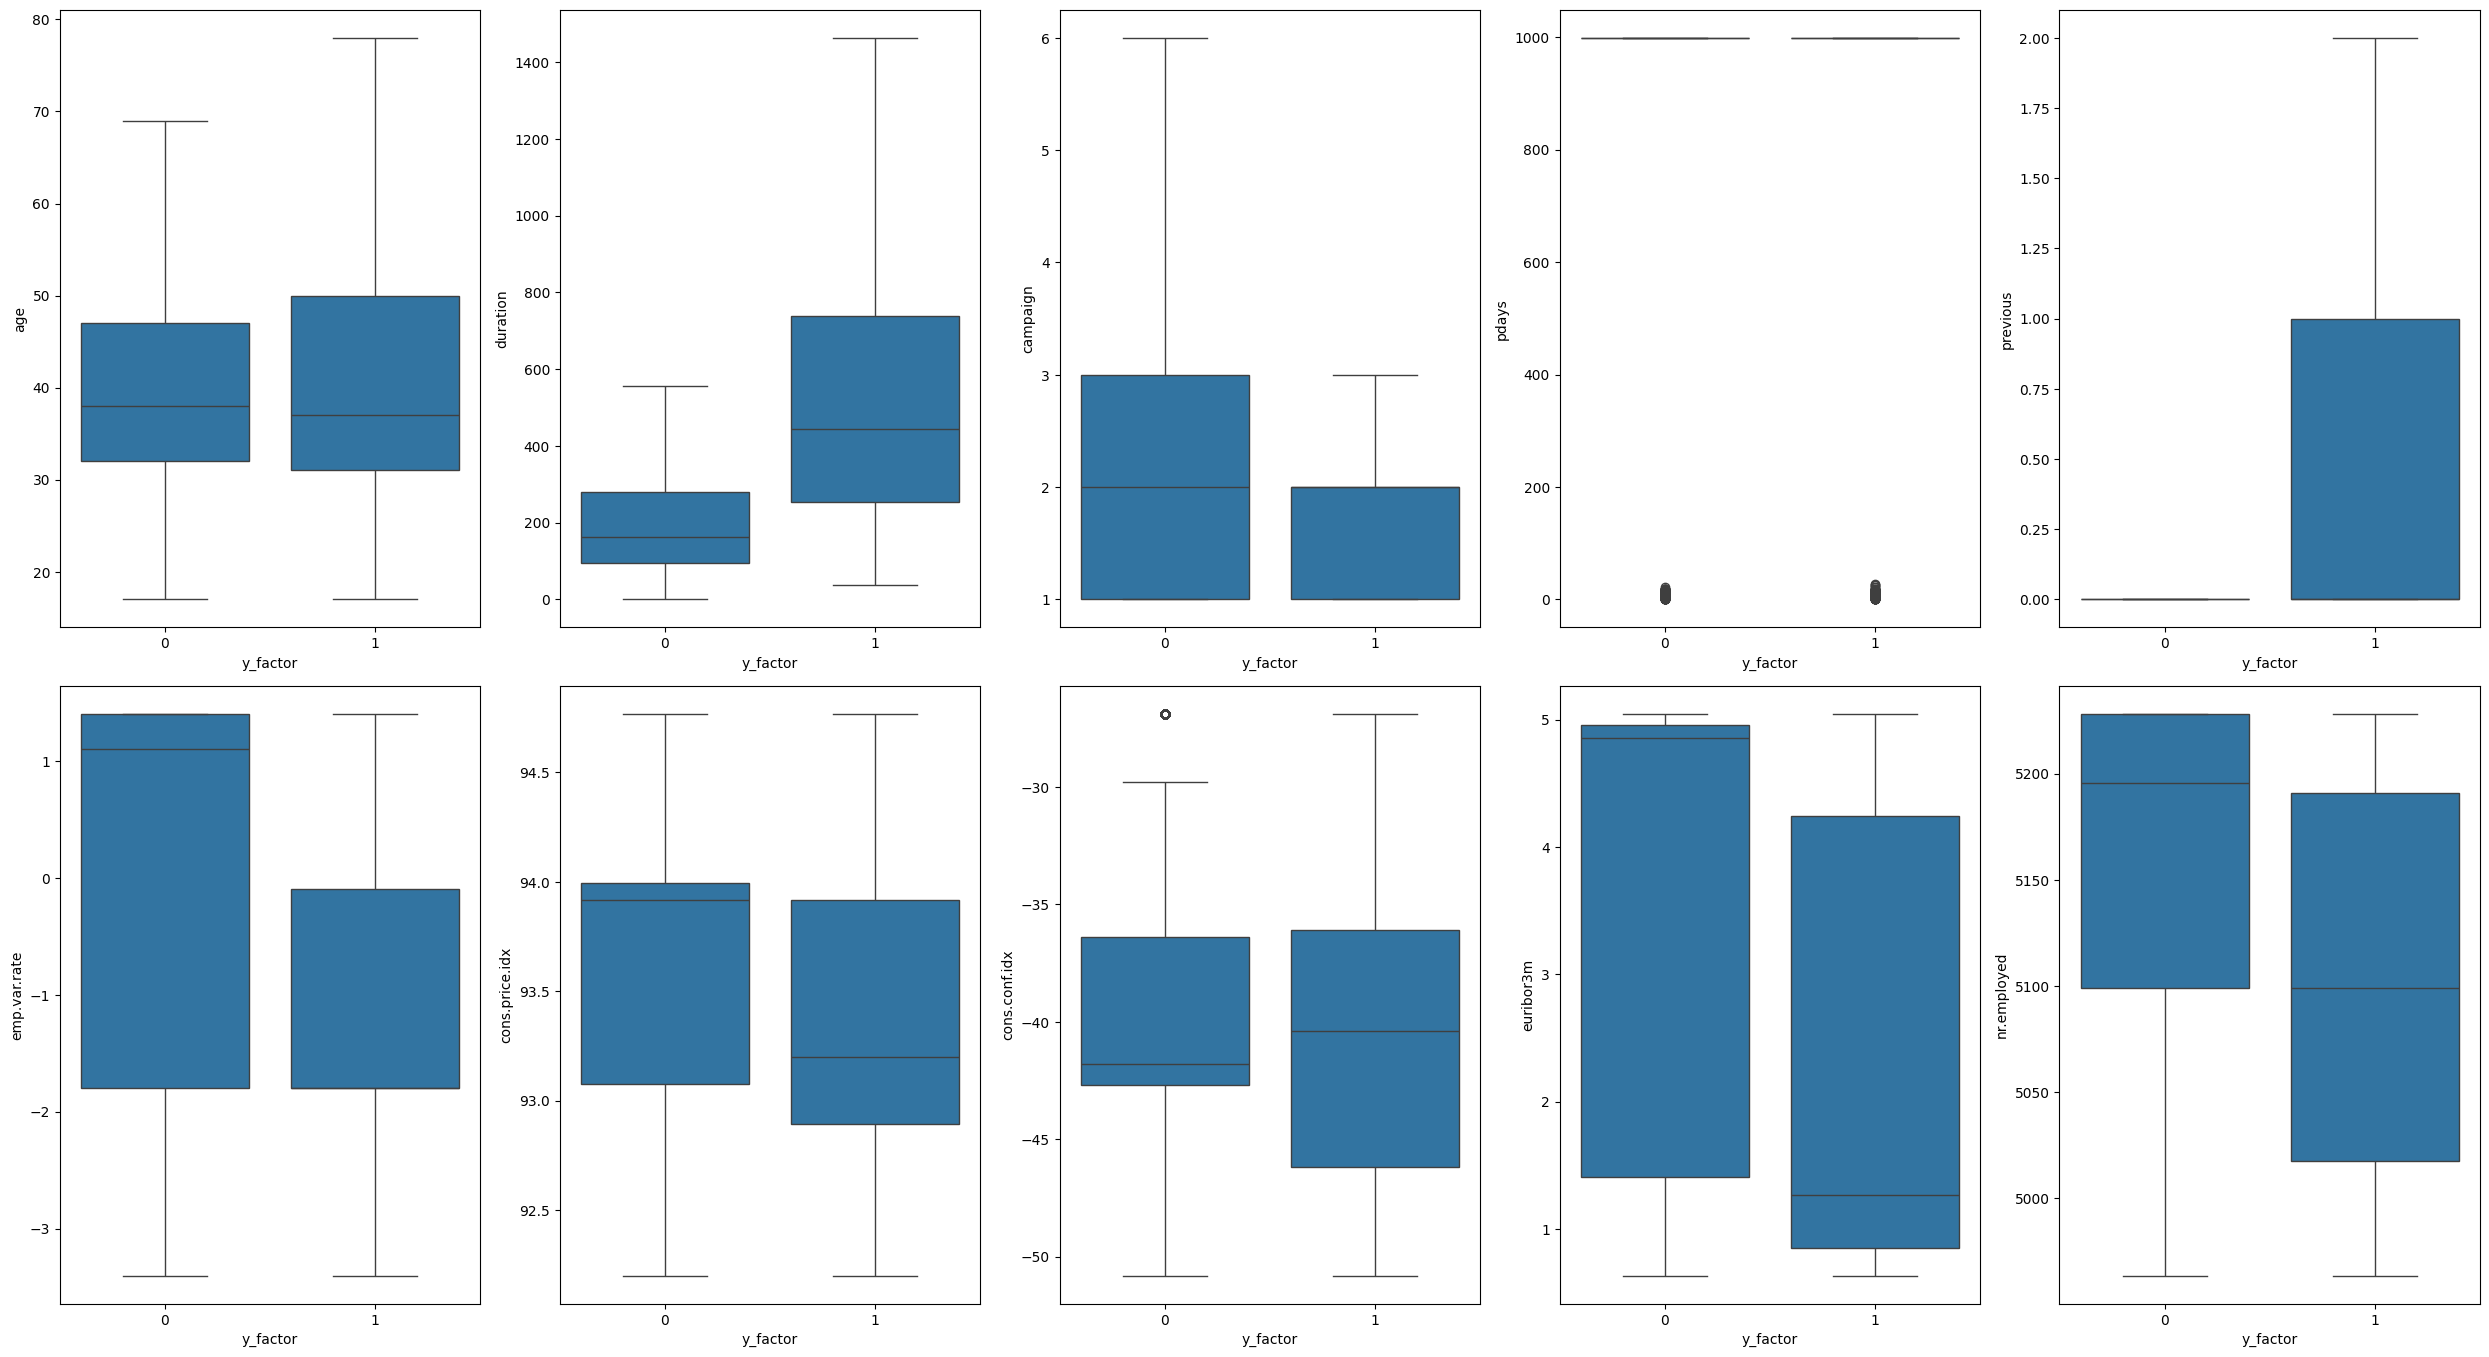

In [46]:
fig = plt.figure(figsize=(25, 20))

# Creamos el grid de 3x5
axis = gridspec.GridSpec(3, 5, figure=fig)
# Los primeros 4 graficos tienen muchos ouliers que afectar la visualizacion de la caja añadimos showfliers=False para quitarlos de la visualizacion
# axis0 = fig.add_subplot(axis[0, 0]); sns.boxplot(data = train, x = 'y_factor', y = 'age', ax = axis0)
# axis1 = fig.add_subplot(axis[0, 1]); sns.boxplot(data = train, x = 'y_factor', y = 'duration', ax = axis1)
# axis2 = fig.add_subplot(axis[0, 2]); sns.boxplot(data = train, x = 'y_factor', y = 'campaign', ax = axis2)
# axis4 = fig.add_subplot(axis[0, 4]); sns.boxplot(data = train, x = 'y_factor', y = 'previous', ax = axis4)

axis0 = fig.add_subplot(axis[0, 0]); sns.boxplot(data = train, x = 'y_factor', y = 'age', ax = axis0, showfliers=False)
axis1 = fig.add_subplot(axis[0, 1]); sns.boxplot(data = train, x = 'y_factor', y = 'duration', ax = axis1, showfliers=False)
axis2 = fig.add_subplot(axis[0, 2]); sns.boxplot(data = train, x = 'y_factor', y = 'campaign', ax = axis2, showfliers=False)
axis4 = fig.add_subplot(axis[0, 4]); sns.boxplot(data = train, x = 'y_factor', y = 'previous', ax = axis4, showfliers=False)
axis3 = fig.add_subplot(axis[0, 3]); sns.boxplot(data = train, x = 'y_factor', y = 'pdays', ax = axis3)
axis5 = fig.add_subplot(axis[1, 0]); sns.boxplot(data = train, x = 'y_factor', y = 'emp.var.rate', ax = axis5)
axis6 = fig.add_subplot(axis[1, 1]); sns.boxplot(data = train, x = 'y_factor', y = 'cons.price.idx', ax = axis6)
axis7 = fig.add_subplot(axis[1, 2]); sns.boxplot(data = train, x = 'y_factor', y = 'cons.conf.idx', ax = axis7)
axis8 = fig.add_subplot(axis[1, 3]); sns.boxplot(data = train, x = 'y_factor', y = 'euribor3m', ax = axis8)
axis9 = fig.add_subplot(axis[1, 4]); sns.boxplot(data = train, x = 'y_factor', y = 'nr.employed', ax = axis9)

# Ajustar Layout para que no se solapen los títulos
plt.tight_layout()
plt.show()

#### Analisis e interpretacion de variables(numericas):
| Variable | Descripción | Analisis |
| :--- | :--- | :--- |
| **age** | Edad del cliente | Las Dos Cajas son muy parecidas pero el bigote de los que contrataron el servicio esta un poco mas alto, puede indicar que personas por encima de los 70 años son mas propensas a contratar el servicio |
| **duration** | Duración del último contacto (segundos) | Aca vemos que la segunda caja casi supera a la primera, indicante que mientras mmas dure la llamada es mas la persona es mas propensa a contratar el servicio, Las otras probablemente colgaron o dirjeron un rotundo "No, Gracias"  |
| **campaign** | Número de contactos en esta campaña | La primera Caja es significativamente mas alta que la segunda, se puede concluir aca que por mas llamadas que se hagan a un cliente no cambiaran de opinion la mayoria de las veces. |
| **pdays** | Días desde el último contacto en campaña previa | podemos observar que ni se ven las cajas casi todos los valores estan cerca de 1000 casi que diciendonos que no ha habido contacto(podemos decir esos valores en 1000 representan nada en lugar de dias), aca los outliers pueden ser clave pero creo que vamos a transformar esta variable. |
| **previous** | Número de contactos previos a esta campaña | podemos observar que los datos de la primera caja estan comprimidos o aplastados haciendo que la mayoria de los datos esten aca, podemos decir que la mayoria son clientes nuevos, pero hay unos pocos que representan la segunda caja e indican que puede haber fidelidad de clientes que hayan sido contactado antes. |
| **emp.var.rate** | Tasa de variación del empleo (trimestral) | Un variable con resultados extraños, mientras cuando las variacion de empleo en positivo (es decir estables) no provocaron que los clientes contrataran, la variacion negativa de la segunda caja (la media que es -1.8 aprox) nos indica que mientras menos estable fue el empleo mas contrataciones hubo. |
| **cons.price.idx**| Índice de precios al consumidor (mensual) | esta variable ya es un poco mas consistente representa la inflacion, mientras que la primera caja hubo in indice alto(cosas mas caras) no hubo contrato, por otra parte la segunda caja que tiene una media mas baja, indica que si hubo menos imflacion(cosas mas baratas) las personas fueron mas propensas a depositar. |
| **cons.conf.idx** | Índice de confianza del consumidor (mensual) | ambas cajas estan en negativo y sus medias se paracen, indica que aunque algunos contrataron y otros no, ambos estan pesimistas pero la segunda caja esta ligeramente por arriba, haciendo que si eres menos pesimista seas mas propenso a contratar el servicio a largo plazo del banco. |
| **euribor3m** | Tasa EURIBOR 3 meses (diario) | El EURIBOR son los intereses que se pagan los bancos entre si, aunque no afecta directamente al cliente,indirectamente afecta a los intereses que les da el banco, pero en nuestro grafico la media de la primera caja 4.8 aprox es mas alta que la segunda 1.3 aprox es un poco contradictorio pero puede tener que ver con la especulacion cuando hay intereses altos |
| **nr.employed** | Número de empleados (trimestral) | Otro punto extraño, cuando hubo mas empleabilidad hubieron menos adquisicion de servicios, puede indicar que el banco tiene mejor exito en las crisis, suele pasar con algunas empresas que aprovenchan las crisi como oportunidades |

In [47]:
#Transformamos pdays vamos a convertir esos valores cerca de 1000 en no contactado y el resto en contractado ya que dispara mucho el rango de los valores
def pdays_transf(v):
    if int(v) >= 990:
        return 0
    else:
        return 1 
create_factor_transf_and_json("pdays", train,"BancoEjercicio2",True,pdays_transf)
train.head()

Json guardado en: ../data/processed/tranformations/BancoEjercicio2\pdays_transformation_rules.json


,age,default,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,marital_factor,education_factor,housing_factor,loan_factor,contact_factor,month_factor,poutcome_factor,day_of_week_factor,y_factor,pdays_transf
8871,37,unknown,218,1,0,1.4,94.465,-41.8,4.866,5228.1,...,0,0,0,0,0,0,0,0,0,0
23616,42,no,2372,3,0,1.4,93.444,-36.1,4.962,5228.1,...,0,1,0,1,1,1,0,0,1,0
11023,25,no,121,2,0,1.4,94.465,-41.8,4.962,5228.1,...,0,2,0,0,0,0,0,1,0,0
30525,31,no,63,3,0,-1.8,92.893,-46.2,1.354,5099.1,...,1,3,1,1,1,2,0,2,0,0
9932,36,no,183,9,0,1.4,94.465,-41.8,4.959,5228.1,...,0,4,1,0,0,0,0,1,0,0


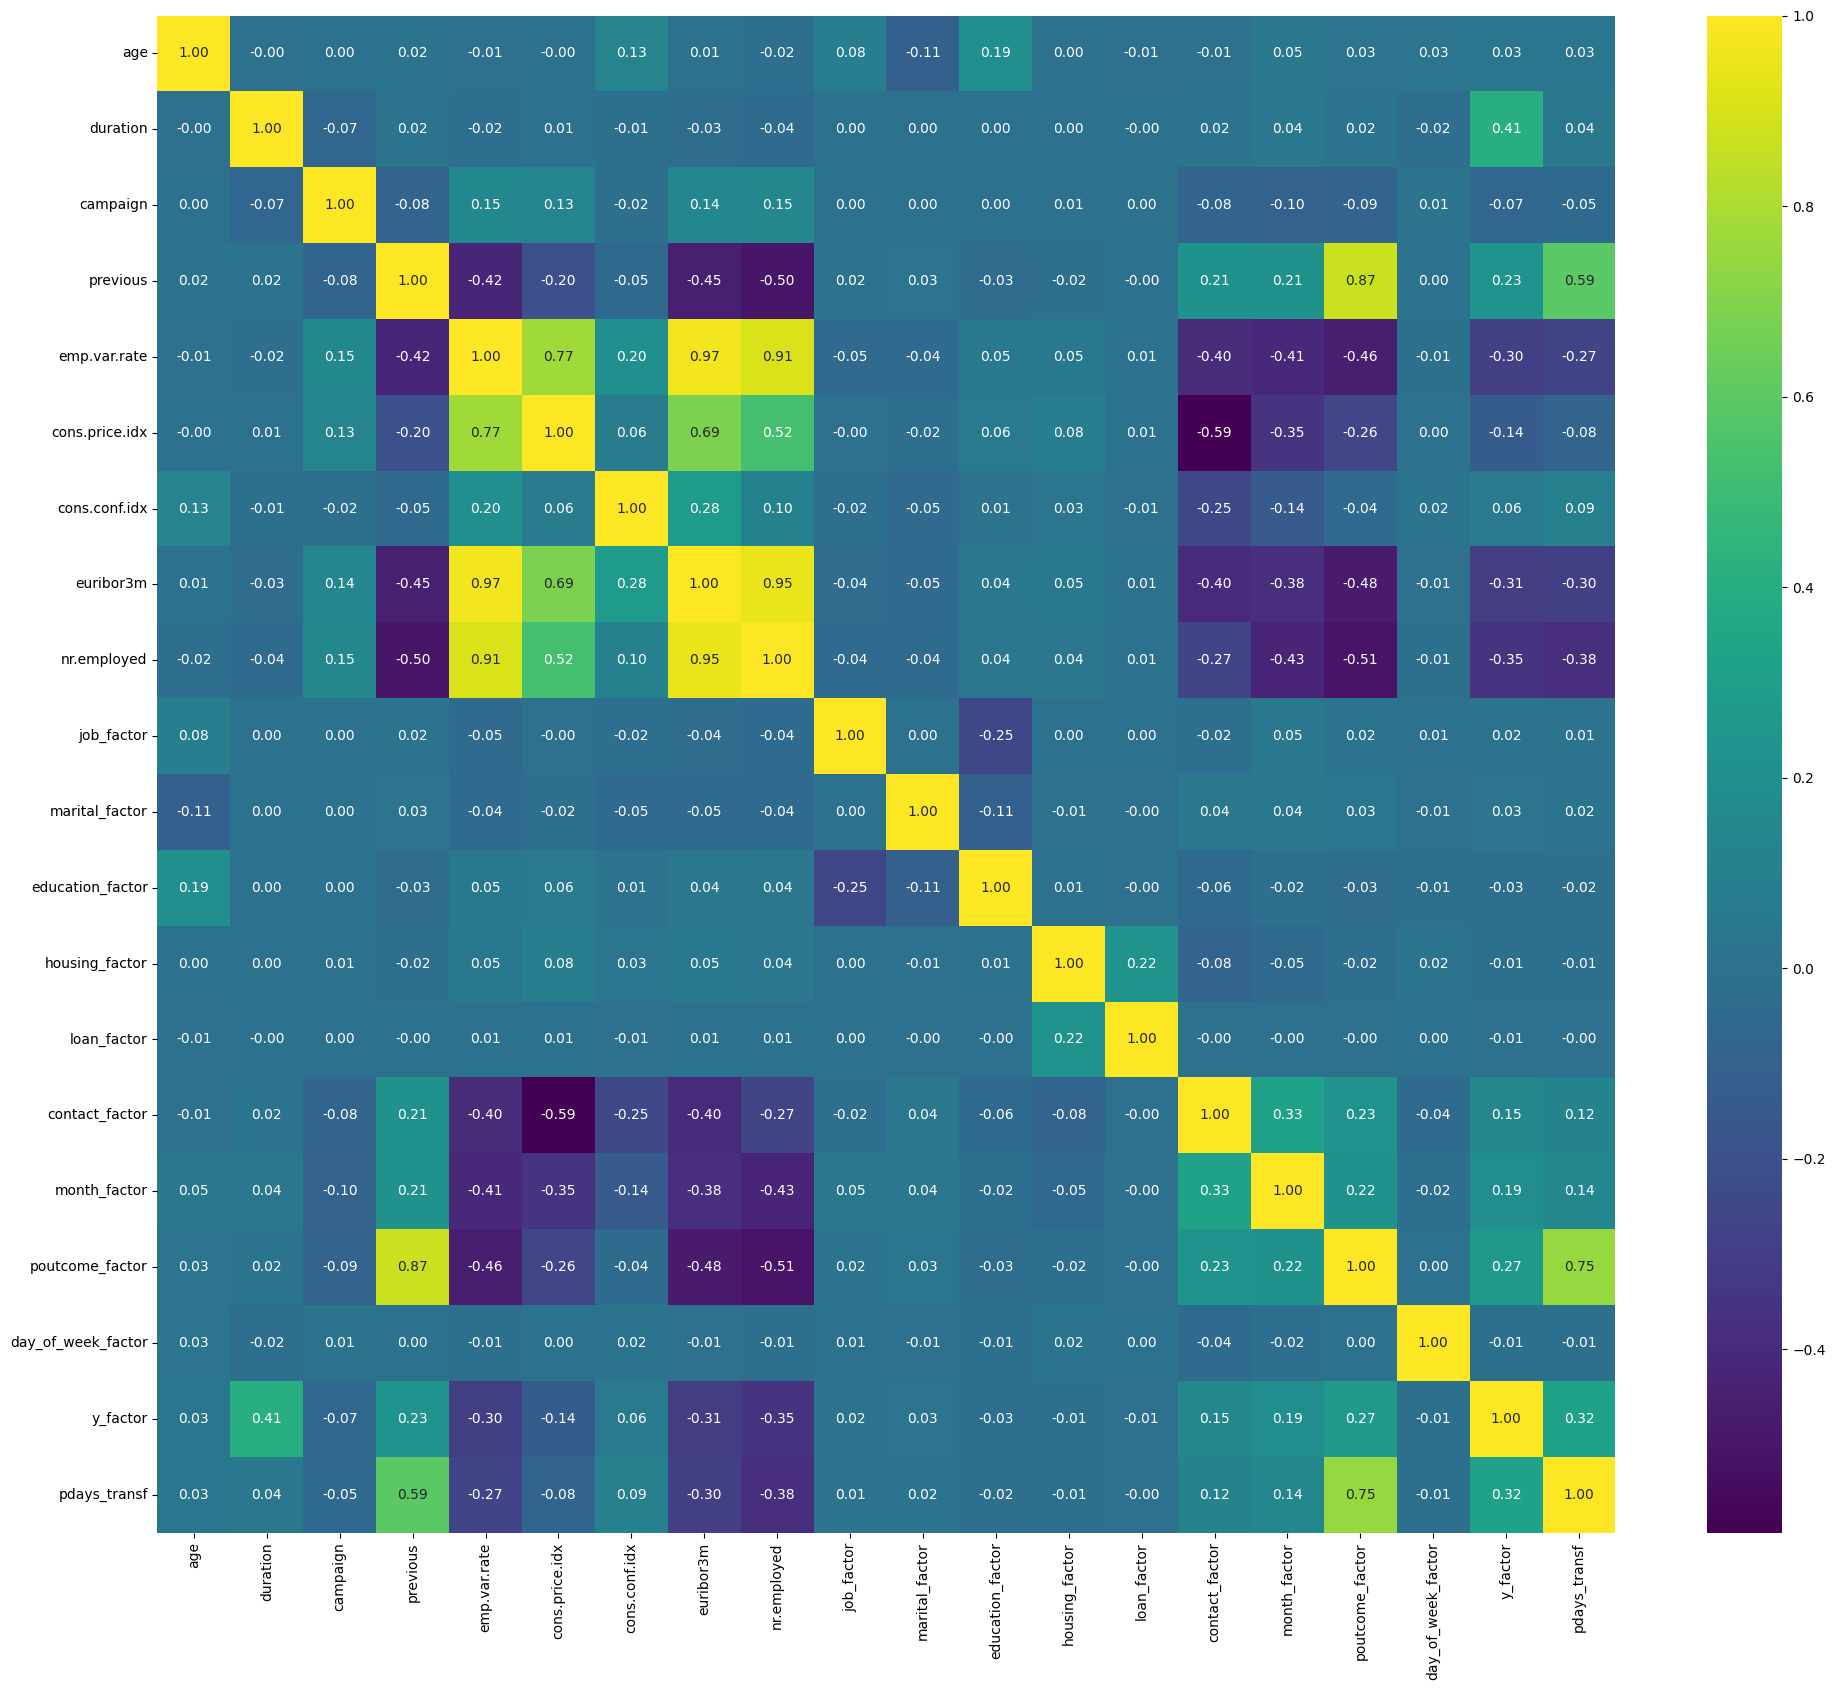

In [51]:
#Graficamos en un heatmap para ver las correlaciones
cols_num = train.select_dtypes(include=['number']).columns
fig, ax = plt.subplots(figsize=(20,  17))
sns.heatmap(train[cols_num].corr(method = "pearson"), annot = True, fmt = ".2f", cmap = "viridis",ax = ax)
plt.tight_layout()
plt.show()

# HOLY SH!@# !! :( :( :(